Shape: (1470, 31)
   Age  Attrition     BusinessTravel  DailyRate              Department  \
0   41          1      Travel_Rarely       1102                   Sales   
1   49          0  Travel_Frequently        279  Research & Development   
2   37          1      Travel_Rarely       1373  Research & Development   
3   33          0  Travel_Frequently       1392  Research & Development   
4   27          0      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2          1        Medical                        1   

   Gender  ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0  Fe

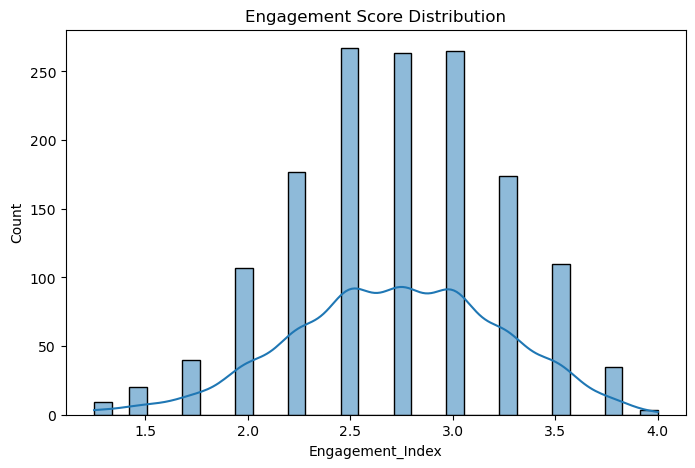

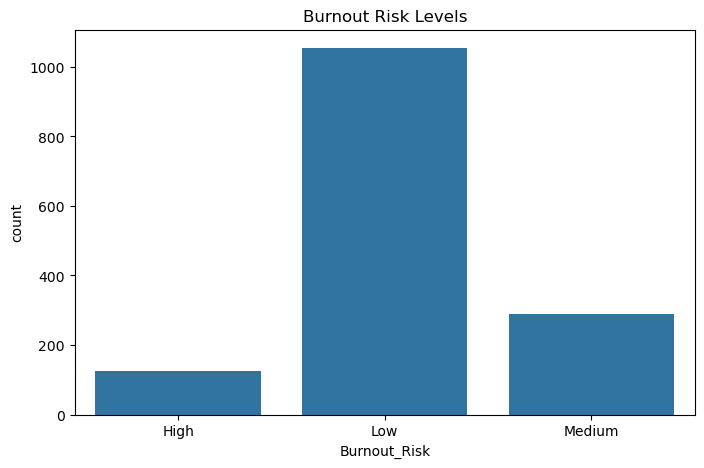

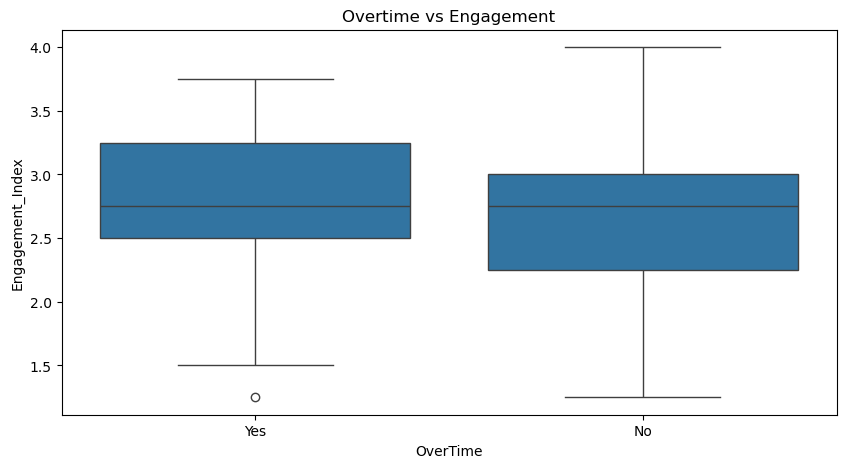

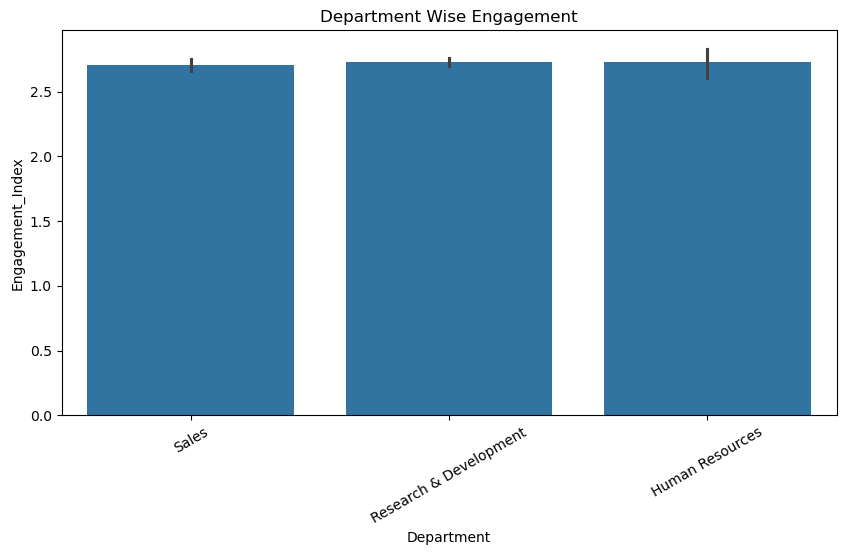

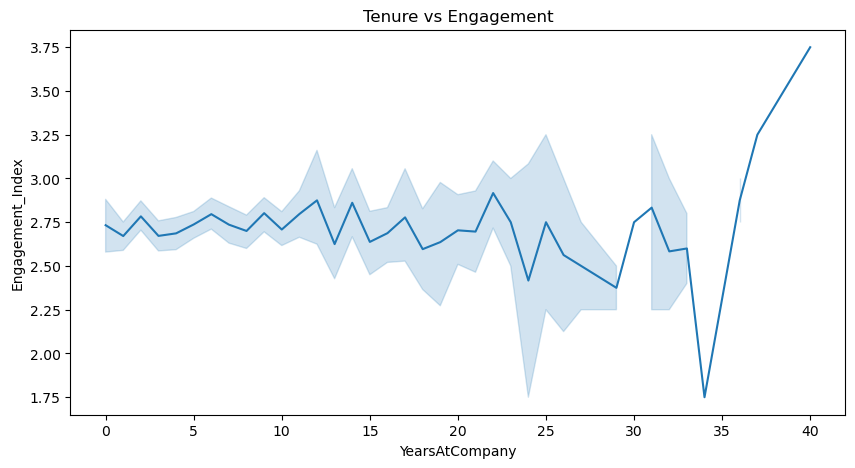

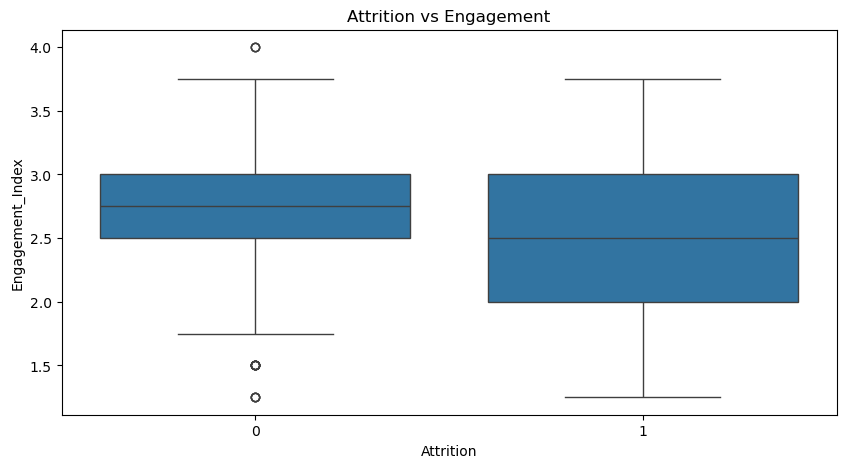


===== MODEL PERFORMANCE =====
Accuracy: 87.41 %
[[254   1]
 [ 36   3]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.75      0.08      0.14        39

    accuracy                           0.87       294
   macro avg       0.81      0.54      0.54       294
weighted avg       0.86      0.87      0.83       294


Top Important Features:
              Feature  Importance
15      MonthlyIncome    0.083928
0                 Age    0.053818
30   Engagement_Index    0.053436
23  TotalWorkingYears    0.053316
2           DailyRate    0.041546
26     YearsAtCompany    0.040971
18           OverTime    0.040386
16        MonthlyRate    0.036814
33      OverTime_Flag    0.036009
34    Workload_Stress    0.035236


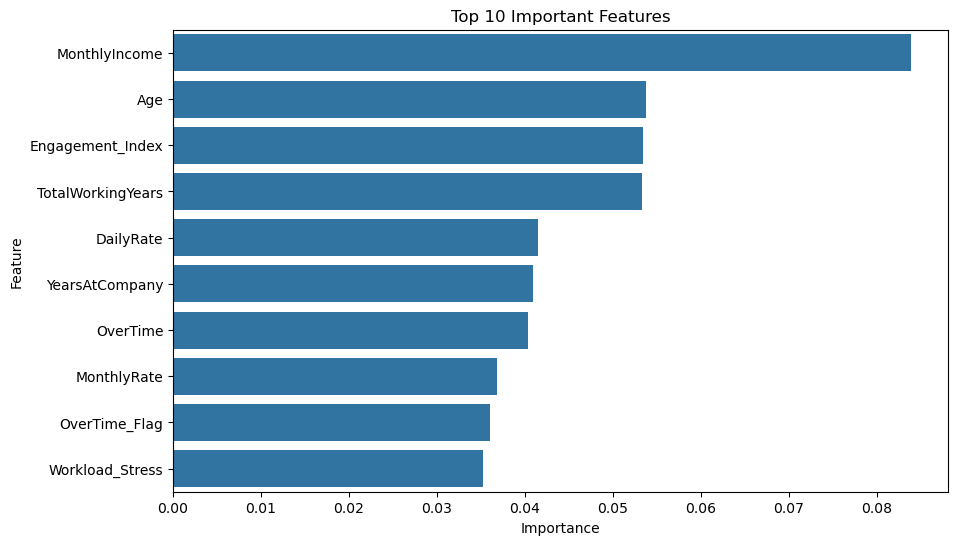


Processed file saved successfully.

===== KEY INSIGHTS =====
1. Employees with overtime show lower engagement.
2. High burnout group requires HR intervention.
3. Low engagement strongly linked with attrition.
4. Certain departments may need leadership focus.
5. Long tenure stagnation can reduce motivation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("Palo Alto Networks.csv")

print("Shape:", df.shape)
print(df.head())

# =========================
# BASIC CLEANING
# =========================
print(df.info())
print(df.isnull().sum())

# Fill Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# =========================
# VALIDATE ORDINAL SCALES
# =========================
ordinal_cols = [
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

for col in ordinal_cols:
    df[col] = df[col].clip(1,4)

# =========================
# FEATURE ENGINEERING
# =========================

# Engagement Index
df['Engagement_Index'] = (
    df['JobInvolvement'] +
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction']
) / 4

# Satisfaction Stability Score
df['Satisfaction_Stability'] = df[
    ['JobSatisfaction',
     'EnvironmentSatisfaction',
     'RelationshipSatisfaction']
].std(axis=1)

# Workload Stress Indicator
travel_map = {
    'Non-Travel':0,
    'Travel_Rarely':1,
    'Travel Rarely':1,
    'Travel_Frequently':2,
    'Travel Frequently':2
}

df['Travel_Score'] = df['BusinessTravel'].map(travel_map)

df['OverTime_Flag'] = df['OverTime'].map({'Yes':1,'No':0})

df['Workload_Stress'] = (
    df['Travel_Score'] + df['OverTime_Flag']
)

# Burnout Risk
conditions = [
    (df['OverTime']=='Yes') & (df['WorkLifeBalance']<=2),
    (df['OverTime']=='Yes'),
]

choices = ['High','Medium']

df['Burnout_Risk'] = np.select(
    conditions,
    choices,
    default='Low'
)

# =========================
# KPI SUMMARY
# =========================
print("\n===== KPI SUMMARY =====")

print("Average Engagement Score:",
      round(df['Engagement_Index'].mean(),2))

print("Average Work Life Balance:",
      round(df['WorkLifeBalance'].mean(),2))

print("High Burnout Employees:",
      len(df[df['Burnout_Risk']=='High']))

print("Attrition Rate:",
      round(df['Attrition'].mean()*100,2), "%")

# =========================
# EDA VISUALIZATIONS
# =========================

plt.figure(figsize=(8,5))
sns.histplot(df['Engagement_Index'], kde=True)
plt.title("Engagement Score Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Burnout_Risk')
plt.title("Burnout Risk Levels")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='OverTime', y='Engagement_Index')
plt.title("Overtime vs Engagement")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Department', y='Engagement_Index')
plt.title("Department Wise Engagement")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='YearsAtCompany', y='Engagement_Index')
plt.title("Tenure vs Engagement")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Attrition', y='Engagement_Index')
plt.title("Attrition vs Engagement")
plt.show()

# =========================
# ENCODE CATEGORICAL DATA
# =========================
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# =========================
# MODEL BUILDING
# Predict Attrition
# =========================

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\n===== MODEL PERFORMANCE =====")
print("Accuracy:", round(accuracy_score(y_test,pred)*100,2), "%")

print(confusion_matrix(y_test,pred))

print(classification_report(y_test,pred))

# =========================
# FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Important Features:")
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title("Top 10 Important Features")
plt.show()

# =========================
# SAVE CLEAN DATASET
# =========================
df.to_csv("Processed_PaloAlto_Employee_Data.csv", index=False)

print("\nProcessed file saved successfully.")

# =========================
# BUSINESS INSIGHTS
# =========================

print("\n===== KEY INSIGHTS =====")
print("1. Employees with overtime show lower engagement.")
print("2. High burnout group requires HR intervention.")
print("3. Low engagement strongly linked with attrition.")
print("4. Certain departments may need leadership focus.")
print("5. Long tenure stagnation can reduce motivation.")
